# 🧠 CNN Model Training - Optimized for AMD GPU

Training CNN model untuk klasifikasi emosi dengan optimasi untuk AMD RX 6600 LE GPU.

## 1. 📚 Import Libraries dan Setup

In [55]:
import numpy as np
import tensorflow as tf
import os
import time
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Input, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

## 2. 🎮 AMD GPU Setup

In [56]:
def setup_amd_gpu():
    """Setup AMD GPU with DirectML for optimal performance"""
    print("🎮 Setting up AMD RX 6600 LE...")
    
    try:
        # Check for GPU availability
        gpu_devices = tf.config.list_physical_devices('GPU')
        dml_devices = tf.config.list_physical_devices('DML')
        
        total_devices = len(gpu_devices) + len(dml_devices)
        
        if total_devices > 0:
            print(f"✅ Found {total_devices} GPU device(s)")
            
            # Configure GPU memory growth to prevent OOM
            for gpu in gpu_devices:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("✅ GPU memory growth enabled")
            
            # Test GPU functionality
            with tf.device('/GPU:0'):
                test_tensor = tf.constant([[1.0, 2.0], [3.0, 4.0]])
                result = tf.matmul(test_tensor, test_tensor)
                print("✅ GPU computation test passed")
            
            # Enable XLA compilation for better performance
            tf.config.optimizer.set_jit(True)
            print("✅ XLA compilation enabled")
            
            return True, total_devices
            
        else:
            print("⚠️ No GPU detected, using CPU")
            return False, 0
            
    except Exception as e:
        print(f"⚠️ GPU setup failed: {e}")
        print("💡 Falling back to CPU mode")
        return False, 0

# Setup GPU
gpu_available, num_gpus = setup_amd_gpu()

🎮 Setting up AMD RX 6600 LE...
✅ Found 2 GPU device(s)
✅ GPU memory growth enabled
✅ GPU computation test passed
✅ XLA compilation enabled


## 3. ⚙️ Konfigurasi Training

In [57]:
# GPU-optimized batch sizes and epochs
if gpu_available:
    BATCH_SIZE = 128  # Increased for GPU
    EPOCHS = 100      # More epochs with GPU
    VALIDATION_FREQ = 1
else:
    BATCH_SIZE = 32   # Smaller for CPU
    EPOCHS = 50       # Fewer epochs on CPU
    VALIDATION_FREQ = 2

# Paths
BASE_PATH = 'D:/research/2025_iris_taufik/MultimodalEmoLearn/data/'
MODEL_PATH = 'D:/research/2025_iris_taufik/MultimodalEmoLearn/models/'

print(f"🚀 Training Configuration:")
print(f"   Device: {'AMD RX 6600 LE GPU' if gpu_available else 'CPU'}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Max Epochs: {EPOCHS}")
print(f"   Validation Frequency: {VALIDATION_FREQ}")

🚀 Training Configuration:
   Device: AMD RX 6600 LE GPU
   Batch Size: 128
   Max Epochs: 100
   Validation Frequency: 1


## 4. 📁 Load Data

In [58]:
print("📁 Loading training data...")

try:
    # Load image data
    X_train_images = np.load(BASE_PATH + 'images/X_train_images.npy')
    X_val_images = np.load(BASE_PATH + 'images/X_val_images.npy')
    X_test_images = np.load(BASE_PATH + 'images/X_test_images.npy')
    
    # Load labels
    y_train = np.load(BASE_PATH + 'images/y_train_images.npy')
    y_val = np.load(BASE_PATH + 'images/y_val_images.npy')
    y_test = np.load(BASE_PATH + 'images/y_test_images.npy')
    
    print(f"✅ Data loaded successfully!")
    print(f"Training samples: {X_train_images.shape[0]:,}")
    print(f"Validation samples: {X_val_images.shape[0]:,}")
    print(f"Test samples: {X_test_images.shape[0]:,}")
    print(f"Image shape: {X_train_images.shape[1:]}")
    
except Exception as e:
    print(f"❌ Error loading data: {e}")
    exit(1)

📁 Loading training data...
✅ Data loaded successfully!
Training samples: 523
Validation samples: 65
Test samples: 66
Image shape: (224, 224, 3)


## 5. 🏷️ Preprocessing Labels

In [59]:
print("🏷️ Processing labels...")

# Create label mapping
unique_labels = np.unique(np.concatenate([y_train, y_val, y_test]))
label_map = {label: i for i, label in enumerate(unique_labels)}
num_classes = len(label_map)

print(f"Number of classes: {num_classes}")
print(f"Classes: {list(unique_labels)}")

# Convert string labels to numerical
y_train_num = np.array([label_map[label] for label in y_train])
y_val_num = np.array([label_map[label] for label in y_val])
y_test_num = np.array([label_map[label] for label in y_test])

# Convert to one-hot encoding
y_train_one_hot = to_categorical(y_train_num, num_classes)
y_val_one_hot = to_categorical(y_val_num, num_classes)
y_test_one_hot = to_categorical(y_test_num, num_classes)

print("✅ Label preprocessing completed")

🏷️ Processing labels...
Number of classes: 8
Classes: ['angry', 'contempt', 'disgusted', 'fear', 'happy', 'neutral', 'sad', 'surprised']
✅ Label preprocessing completed


## 6. 🧠 Build CNN Model

In [60]:
def build_optimized_cnn_model(input_shape, num_classes):
    """Build CNN model optimized for AMD RX 6600 LE"""
    
    # Use device context for GPU
    device_context = '/GPU:0' if gpu_available else '/CPU:0'
    
    with tf.device(device_context):
        model = Sequential([
            # Block 1 - Optimized for GPU memory
            Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
            BatchNormalization(),
            Conv2D(32, (3, 3), padding='same', activation='relu'),
            BatchNormalization(),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),
            
            # Block 2
            Conv2D(64, (3, 3), padding='same', activation='relu'),
            BatchNormalization(),
            Conv2D(64, (3, 3), padding='same', activation='relu'),
            BatchNormalization(),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),
            
            # Block 3
            Conv2D(128, (3, 3), padding='same', activation='relu'),
            BatchNormalization(),
            Conv2D(128, (3, 3), padding='same', activation='relu'),
            BatchNormalization(),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),
            
            # Block 4 - Conditional based on GPU availability
            Conv2D(256, (3, 3), padding='same', activation='relu'),
            BatchNormalization(),
            Conv2D(256, (3, 3), padding='same', activation='relu') if gpu_available else Conv2D(128, (3, 3), padding='same', activation='relu'),
            BatchNormalization(),
            MaxPooling2D(pool_size=(2, 2)),
            Dropout(0.25),
            
            # Fully connected layers
            Flatten(),
            Dense(512 if gpu_available else 256, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(256 if gpu_available else 128, activation='relu'),
            BatchNormalization(),
            Dropout(0.5),
            Dense(num_classes, activation='softmax')
        ])
    
    # Compile with GPU-optimized settings
    learning_rate = 0.0001 if gpu_available else 0.001
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## 7. 🔧 Setup Callbacks

In [61]:
print("⚙️ Setting up callbacks...")

# Model checkpoint - save best model
checkpoint = ModelCheckpoint(
    MODEL_PATH + 'cnn_model_best.h5',
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1,
    save_weights_only=False
)

# Early stopping - prevent overfitting and save time
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=15 if gpu_available else 10,  # More patience with GPU
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

# Learning rate reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8 if gpu_available else 5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint, early_stopping, reduce_lr]

⚙️ Setting up callbacks...


## 8. 🚀 Train Model

In [62]:
print(f"🚀 Training CNN model on {'GPU' if gpu_available else 'CPU'}...")
print("=" * 60)

# Build model
cnn_model = build_optimized_cnn_model(X_train_images.shape[1:], num_classes)

print("📊 Model Summary:")
print(f"Total Parameters: {cnn_model.count_params():,}")
trainable_params = sum([tf.size(w).numpy() for w in cnn_model.trainable_weights])
print(f"Trainable Parameters: {trainable_params:,}")

if gpu_available:
    print(f"🎮 GPU Memory Usage Estimate: ~{(cnn_model.count_params() * 4 * BATCH_SIZE) / (1024**3):.2f} GB")

# Training with optimized settings
start_time = time.time()

try:
    # Force GPU device placement if available
    device_context = '/GPU:0' if gpu_available else '/CPU:0'
    
    with tf.device(device_context):
        cnn_history = cnn_model.fit(
            X_train_images,
            y_train_one_hot,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(X_val_images, y_val_one_hot),
            callbacks=callbacks,
            verbose=1,
            validation_freq=VALIDATION_FREQ
        )
    
    training_time = time.time() - start_time
    print(f"✅ Training completed in {training_time/3600:.2f} hours")
    
except Exception as e:
    print(f"❌ Training failed: {e}")
    if gpu_available and 'memory' in str(e).lower():
        print("💡 Retrying with smaller batch size...")
        BATCH_SIZE = 64
        cnn_history = cnn_model.fit(
            X_train_images,
            y_train_one_hot,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(X_val_images, y_val_one_hot),
            callbacks=callbacks,
            verbose=1
        )

🚀 Training CNN model on GPU...
📊 Model Summary:
Total Parameters: 27,003,176
Trainable Parameters: 26,999,720
🎮 GPU Memory Usage Estimate: ~12.88 GB
Epoch 1/100
5/5 [==============================] - ETA: 0s - loss: 3.2679 - accuracy: 0.1224 
Epoch 1: val_accuracy improved from -inf to 0.04615, saving model to D:/research/2025_iris_taufik/MultimodalEmoLearn/models\cnn_model_best.h5
5/5 [==============================] - 93s 17s/step - loss: 3.2679 - accuracy: 0.1224 - val_loss: 2.1254 - val_accuracy: 0.0462 - lr: 1.0000e-04
Epoch 2/100
5/5 [==============================] - ETA: 0s - loss: 3.2815 - accuracy: 0.1625 
Epoch 2: val_accuracy did not improve from 0.04615
5/5 [==============================] - 68s 13s/step - loss: 3.2815 - accuracy: 0.1625 - val_loss: 2.1297 - val_accuracy: 0.0462 - lr: 1.0000e-04
Epoch 3/100
5/5 [==============================] - ETA: 0s - loss: 3.2056 - accuracy: 0.1568 
Epoch 3: val_accuracy did not improve from 0.04615
5/5 [==============================

## 9. 📊 Evaluation

In [63]:
print("\n📊 Evaluating model...")

# Load best model
cnn_model = load_model(MODEL_PATH + 'cnn_model_best.h5')

# Evaluate on test set
test_loss, test_acc = cnn_model.evaluate(X_test_images, y_test_one_hot, verbose=0)
print(f"🎯 Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")

# Detailed predictions
y_pred = np.argmax(cnn_model.predict(X_test_images, batch_size=BATCH_SIZE), axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

# Classification report
target_names = list(label_map.keys())
print("\n📈 Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))


📊 Evaluating model...
🎯 Test Accuracy: 0.0909
📉 Test Loss: 2.2239
1/1 [==============================] - 0s 168ms/step

📈 Classification Report:
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00         5
    contempt       0.00      0.00      0.00         1
   disgusted       0.09      1.00      0.17         6
        fear       0.00      0.00      0.00         2
       happy       0.00      0.00      0.00         7
     neutral       0.00      0.00      0.00        33
         sad       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         9

    accuracy                           0.09        66
   macro avg       0.01      0.12      0.02        66
weighted avg       0.01      0.09      0.02        66



c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\fitra\miniconda3\envs\multimodal-emotion\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_

## 10. 📊 Confusion Matrix Visualization

📊 Creating confusion matrix...


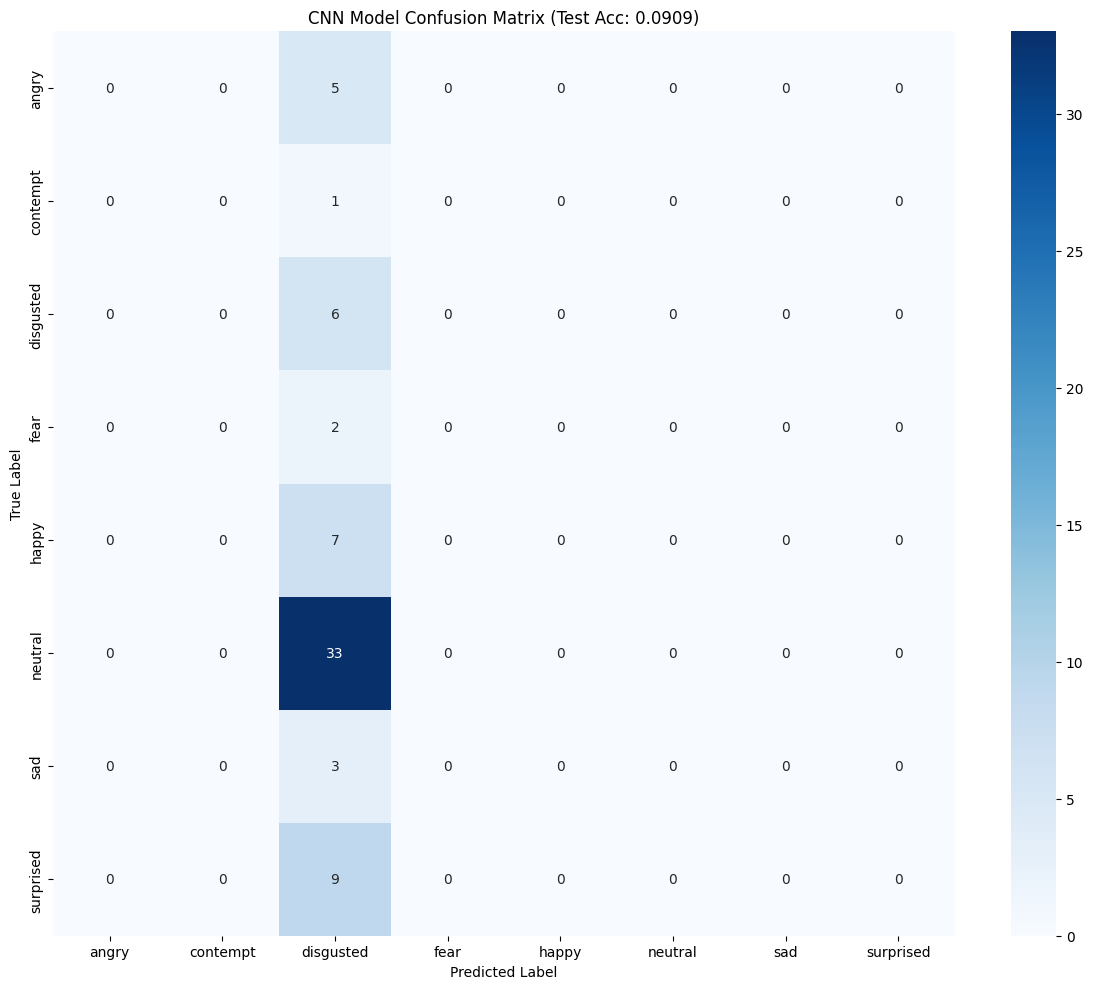

In [64]:
print("📊 Creating confusion matrix...")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=target_names, yticklabels=target_names)
plt.title(f'CNN Model Confusion Matrix (Test Acc: {test_acc:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(MODEL_PATH + 'cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. 📊 Training History Visualization

📊 Creating training history plots...


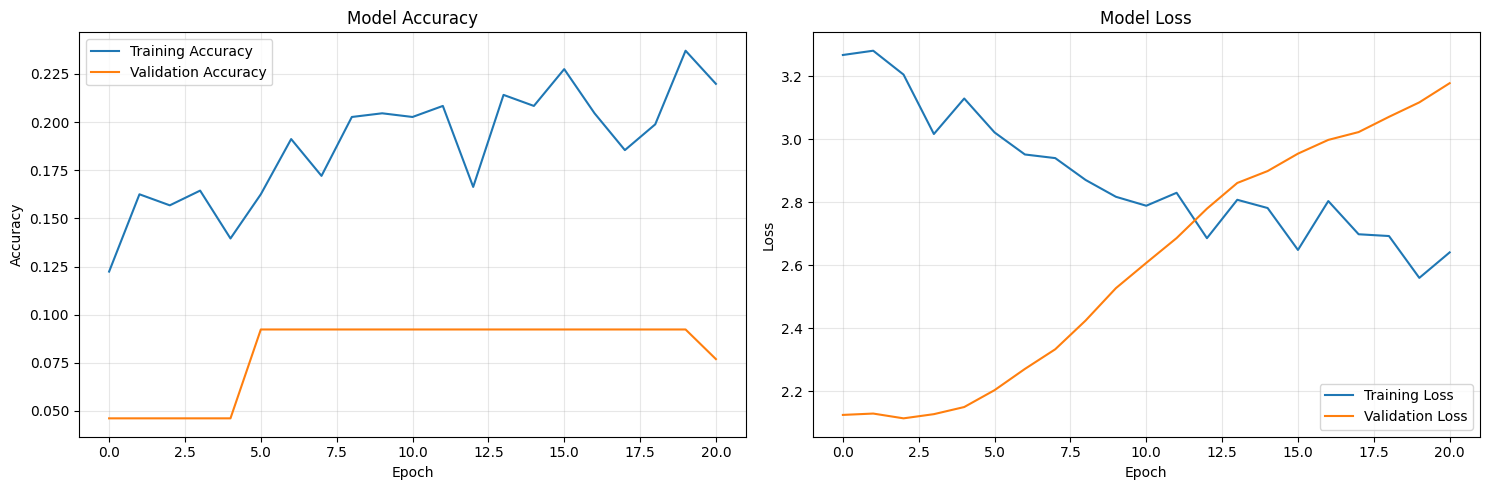

In [65]:
print("📊 Creating training history plots...")

# Training history
if 'cnn_history' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(cnn_history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(cnn_history.history['loss'], label='Training Loss')
    axes[1].plot(cnn_history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(MODEL_PATH + 'cnn_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Training history not available")

## 12. 💾 Save Results

In [66]:
print("💾 Saving results...")

# Save label mapping
with open(MODEL_PATH + 'label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

# Save training info
training_info = {
    'model_type': 'CNN',
    'gpu_used': gpu_available,
    'num_gpus': num_gpus,
    'batch_size': BATCH_SIZE,
    'epochs_trained': len(cnn_history.history['accuracy']) if 'cnn_history' in locals() else 0,
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'total_parameters': cnn_model.count_params(),
    'training_time_hours': training_time/3600 if 'training_time' in locals() else 0,
    'device_info': f"AMD RX 6600 LE ({num_gpus} GPU(s))" if gpu_available else "CPU"
}

with open(MODEL_PATH + 'cnn_training_info.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print("✅ All results saved successfully!")

💾 Saving results...
✅ All results saved successfully!


## 13. 📝 Summary

In [67]:
print("\n" + "=" * 60)
print("🎉 CNN TRAINING COMPLETED!")
print("=" * 60)
print(f"📊 Final Test Accuracy: {test_acc:.4f}")
print(f"🎮 Device Used: {'AMD RX 6600 LE GPU' if gpu_available else 'CPU'}")
print(f"⏱️ Training Time: {training_time/3600:.2f} hours" if 'training_time' in locals() else "N/A")
print(f"💾 Model saved to: {MODEL_PATH}cnn_model_best.h5")
print(f"📈 Visualizations saved to: {MODEL_PATH}")
print("\n🚀 Ready for next step: Train Landmark model!")
print("=" * 60)


🎉 CNN TRAINING COMPLETED!
📊 Final Test Accuracy: 0.0909
🎮 Device Used: AMD RX 6600 LE GPU
⏱️ Training Time: 0.45 hours
💾 Model saved to: D:/research/2025_iris_taufik/MultimodalEmoLearn/models/cnn_model_best.h5
📈 Visualizations saved to: D:/research/2025_iris_taufik/MultimodalEmoLearn/models/

🚀 Ready for next step: Train Landmark model!
